<a href="https://colab.research.google.com/github/JG0724/IT480-FA26/blob/main/Assignments/Assignment%202/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(replace with your name)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [ ]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: JG0724
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:07<00:00, 57.1MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [ ]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [ ]:
# Your exploration here
import os

print("Images per class:")
for class_name in class_names_fire:
    class_path = os.path.join(data_dir_fire, class_name)
    count = len(os.listdir(class_path))
    print(f"- {class_name}: {count} images")


Images per class:
- fire_images: 755 images
- non_fire_images: 244 images


*What did you notice about this dataset? Does it change how you'll approach the next steps?*
There is a signifigant class imbalance. Fire_images has significantly more samples than the other. This means that a purely random split could result in a test set that has an extremely low number of images of the non_fire_images.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [ ]:
# Preprocess the data here
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_fire = train_raw_fire.map(lambda x, y: (preprocess_input(x), y))
val_fire = val_raw_fire.map(lambda x, y: (preprocess_input(x), y))
test_fire = test_raw_fire.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
# Build your model here
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Compile your model here
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)



## 1D — Train and Evaluate

In [ ]:
# Train your model here
history = model.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5 #
)



Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.8271 - loss: 0.3460 - val_accuracy: 0.9281 - val_loss: 0.2373
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9614 - loss: 0.1448 - val_accuracy: 0.9712 - val_loss: 0.1363
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.9729 - loss: 0.0996 - val_accuracy: 0.9568 - val_loss: 0.1214
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9843 - loss: 0.0813 - val_accuracy: 0.9640 - val_loss: 0.0851
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9857 - loss: 0.0695 - val_accuracy: 0.9856 - val_loss: 0.0726


In [ ]:
# Report validation and test accuracy here
print("Evaluating on Validation Data:")
val_loss, val_acc = model.evaluate(val_fire)

print("\nEvaluating on Test Data:")
test_loss, test_acc = model.evaluate(test_fire)

print(f"\nFinal Validation Accuracy: {val_acc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Evaluating on Validation Data:
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 904ms/step - accuracy: 0.9640 - loss: 0.0988

Evaluating on Test Data:
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9750 - loss: 0.0898

Final Validation Accuracy: 0.9640
Final Test Accuracy: 0.9750


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step


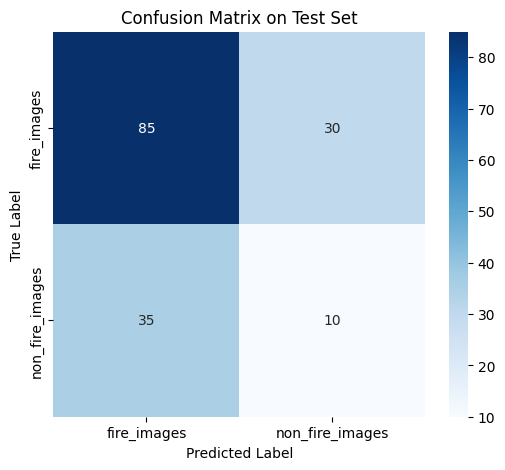

In [ ]:
# Build your confusion matrix here
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_true = np.concatenate([y for x, y in test_fire], axis=0)

y_pred_probs = model.predict(test_fire)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['fire_images', 'non_fire_images'],
            yticklabels=['fire_images', 'non_fire_images'])
plt.title('Confusion Matrix on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

*Your answer:* In the context of fire detection, a false negative is much more costly than a false positive. Missing an actual fire would cause catastrophic damage. To account for this, you would lower the decision threshold. This would increase the sensitivity and trigger a fire prediction even with lower confidence.




---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [ ]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [ ]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [ ]:
# Preprocess the data here (Had issue with Keras here)
train_sat = train_raw_sat.map(lambda x, y: ((x / 127.5) - 1.0, y))
val_sat = val_raw_sat.map(lambda x, y: ((x / 127.5) - 1.0, y))
test_sat = test_raw_sat.map(lambda x, y: ((x / 127.5) - 1.0, y))

In [ ]:
# Build your model here
import tensorflow as tf

base_model_sat = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model_sat.trainable = False

model_sat = tf.keras.Sequential([
    base_model_sat,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(10, activation='softmax')
])


In [ ]:
# Compile your model here
model_sat.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


## 2C — Train and Evaluate

In [24]:
# Train your model here
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 962s 2s/step - accuracy: 0.8773 - loss: 0.3819 - val_accuracy: 0.9289 - val_loss: 0.2231
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 908s 2s/step - accuracy: 0.9350 - loss: 0.1957 - val_accuracy: 0.9371 - val_loss: 0.1911
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 893s 2s/step - accuracy: 0.9464 - loss: 0.1592 - val_accuracy: 0.9386 - val_loss: 0.1870
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 942s 2s/step - accuracy: 0.9531 - loss: 0.1394 - val_accuracy: 0.9316 - val_loss: 0.1963
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 932s 2s/step - accuracy: 0.9599 - loss: 0.1214 - val_accuracy: 0.9438 - val_loss: 0.1699


In [25]:
# Report validation and test accuracy here
print("Evaluating on Validation Data:")
val_loss_sat, val_acc_sat = model_sat.evaluate(val_sat)

print("\nEvaluating on Test Data:")
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat)

print(f"\nFinal Validation Accuracy: {val_acc_sat:.4f}")
print(f"Final Test Accuracy: {test_acc_sat:.4f}")


Evaluating on Validation Data:
127/127 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.9423 - loss: 0.1735

Evaluating on Test Data:
127/127 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9432 - loss: 0.1664

Final Validation Accuracy: 0.9423
Final Test Accuracy: 0.9432


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

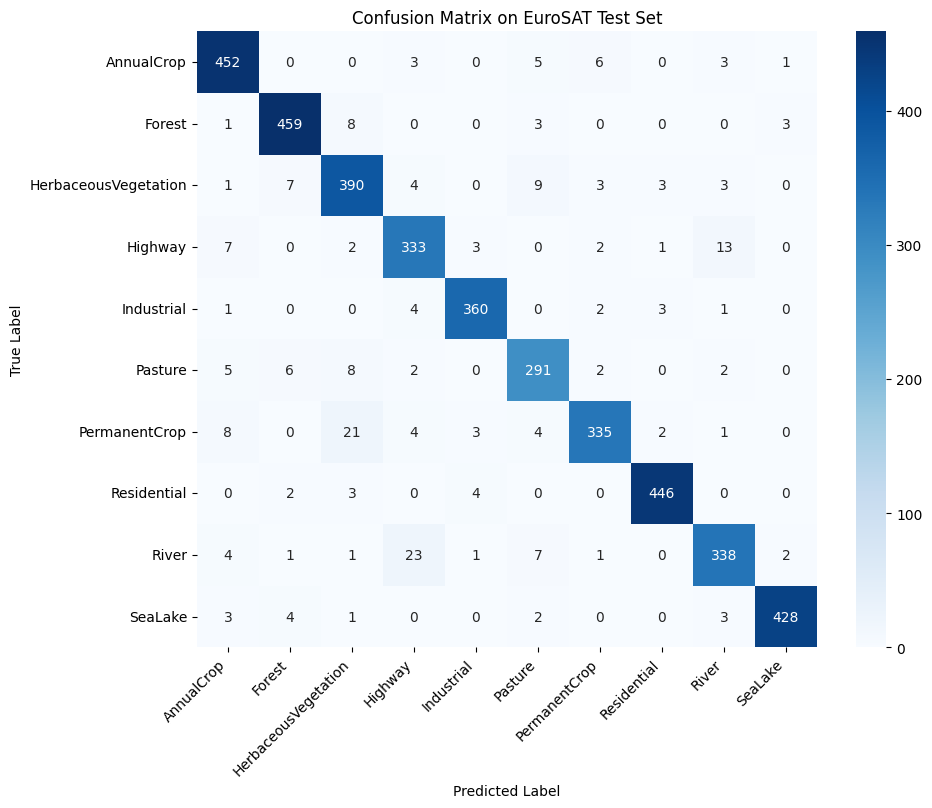

In [27]:
# Build your confusion matrix here
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_true_sat = []
y_pred_probs_sat = []

for images, labels in test_sat:
    y_true_sat.extend(labels.numpy())
    preds = model_sat.predict(images, verbose=0)
    y_pred_probs_sat.extend(preds)

y_true_sat = np.array(y_true_sat)
y_pred_sat = np.argmax(y_pred_probs_sat, axis=1)
cm_sat = confusion_matrix(y_true_sat, y_pred_sat)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_sat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_sat,
            yticklabels=class_names_sat)
plt.title('Confusion Matrix on EuroSAT Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.show()

*Your answer:* Looking at the matrix, the classes that get confused most often are River and Highway. River was misclassified as Highway 23 times, and Highway misclassified as River 13 times. This mix-up was followed closely by PermanentCrop and HerbaceousVegetation.

This would make total sense visually. From a top-down perspective, like that of a satellite, rivers and highways both appear as long, winding ribbons. This similarity is the case for crops and vegetation as well, given they are both textured patches of land with similar features.




---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |.9640 |.9423 |
| Test Accuracy |.9750 |.9432 |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*

1. The fire/smoke dataset is a much closer match to the original ImageNet training data. ImageNet consists of ordinary ground-level photos, whereas EuroSAT uses top-down satellite imagery, causing the bigger mismatch. My results support this. The model achieved 97.5% test accuracy on the fire/smoke dataset, compared to a lower 94.32% test accuracy on the EuroSAT dataset.

2. Yes there is room for improvement if we could adjust the base model itself, and this would have a significant impact for the EuroSAT dataset. Because of the top down perspective being such a mismatch for the original training data, unfreezing the base layers would allow the model to learn domain specific features.




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The fire dataset contains a significant class imbalance, which meant evaluating it required looking closely at false negatives in a confusion matrix rather than purely relying on overall accuracy. Because the first task was binary classification, Part 1 used a single output with sigmoid activation and binary cross-entropy loss. Part 2 required 10 output nodes, softmax, and sparse categorical cross-entropy loss because it was predicting 10 categories.
The results demonstrate that a pretrained models usefulness depends on how well the original training matches the target task. Specifically, the model achieved a higher test accuracy on the ground level fire dataset than the EuroSAT dataset, indicating that the pretained features transferred more effectivvely to the structurally similar domain.

---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.